# Getting Started with KinDER

This notebook walks through the basics of the KinDER benchmark:
discovering available environments, creating one, taking actions,
and rendering a video.

In [1]:
%pip install kindergarden
# Installs all backends. To install just one (e.g. the 2D environments, with no
# PyBullet/MuJoCo), use a requirements file instead -- see the repo's
# requirements/ directory and the README "single backend" install section.

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import kinder

## Discovering Available Environments

KinDER organizes environments into categories. Let's register them all
and see what's available.

In [3]:
kinder.register_all_environments()

categories = kinder.get_env_categories()
for category, env_classes in sorted(categories.items()):
    print(f"{category}: {len(env_classes)} environment classes")
    for cls in env_classes:
        variants = kinder.get_env_variants(cls)
        print(f"  {cls} ({len(variants)} variants)")

Dynamic2D: 4 environment classes
  DynObstruction2D (4 variants)
  DynPushPullHook2D (3 variants)
  DynPushT2D (1 variants)
  DynScoopPour2D (4 variants)
Dynamic3D: 12 environment classes
  Shelf3D (3 variants)
  SortClutteredBlocks3D (4 variants)
  FrankaPickPlace3D (1 variants)
  SweepIntoDrawer3D (1 variants)
  SweepSimple3D (6 variants)
  Dynamo3D (3 variants)
  BalanceBeam3D (1 variants)
  Tossing3D (2 variants)
  ConstrainedCupboard3D (6 variants)
  ScoopPour3D (2 variants)
  PickPlace3D (1 variants)
  Rearrange3D (10 variants)
Kinematic2D: 6 environment classes
  Obstruction2D (5 variants)
  ClutteredRetrieval2D (3 variants)
  ClutteredStorage2D (4 variants)
  Motion2D (6 variants)
  StickButton2D (5 variants)
  PushPullHook2D (1 variants)
Kinematic3D: 7 environment classes
  BaseMotion3D (1 variants)
  Table3D (3 variants)
  Transport3D (2 variants)
  KinematicShelf3D (5 variants)
  PrplLab3D (2 variants)
  Obstruction3D (5 variants)
  Packing3D (3 variants)


pybullet build time: Jun  3 2026 18:02:19


## Creating an Environment

We'll use `Obstruction2D-o3-v0`, a Kinematic2D environment where a robot
must place a block onto a target surface while navigating around obstacles.

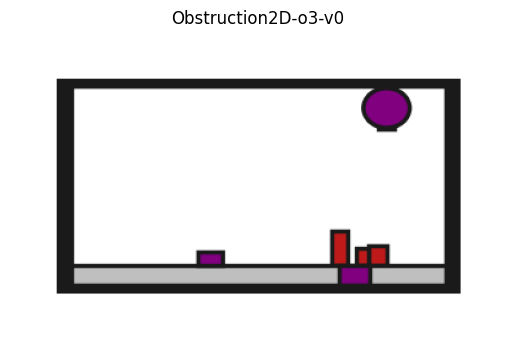

In [4]:
env = kinder.make("kinder/Obstruction2D-o3-v0", render_mode="rgb_array")
obs, info = env.reset(seed=42)

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("Obstruction2D-o3-v0")
plt.show()

## Exploring the Observation and Action Spaces

KinDER environments follow the Gymnasium API. Observations and actions
are continuous-valued numpy arrays.

In [5]:
print("Observation shape:", env.observation_space.shape)
print("Action shape:     ", env.action_space.shape)
print()

action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print("Sample action:", np.round(action, 3))
print("Reward:       ", reward)
print("Terminated:   ", terminated)

Observation shape: (59,)
Action shape:      (5,)

Sample action: [-0.    -0.006 -0.152 -0.029  0.23 ]
Reward:        -1.0
Terminated:    False


## Rendering a Video

Let's collect frames from random actions and display them as an animated GIF.

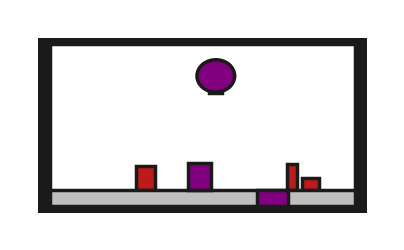

In [6]:
from io import BytesIO

from IPython.display import Image
from PIL import Image as PILImage

obs, info = env.reset(seed=0)
frames = [env.render()]
for _ in range(50):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render())
    if terminated or truncated:
        break

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [7]:
env.close()